In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score
)
import random
import optuna
import torch.optim as optim
import time
import torch.nn.functional as F
import os

In [3]:
df = pd.read_csv('./data/prepared_data_mill13.csv')
df['average_time'] = pd.to_datetime(df['average_time'], format='%Y-%m-%d %H:%M:%S')
df = df.sort_values(by='average_time')
df = df.reset_index(drop=True)
df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg]
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850


In [4]:
df_periodic = pd.read_csv('./data/periodic_selections.csv')
df_periodic['average_time'] = pd.to_datetime(df_periodic['average_time'], format='%Y-%m-%d %H:%M:%S')
df_periodic = df_periodic.reset_index(drop=True)
df_periodic

,Unnamed: 0,Q_bauxite_[t/h],time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg]
0,22,44.8055,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063
1,23,63.8130,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,156.522063
2,24,66.9386,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,156.522063
3,145,91.5623,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946
4,146,97.1414,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,61.150946
...,...,...,...,...,...,...,...,...,...,...,...,...
161,167,36.9784,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,45.417568
162,168,46.2246,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,45.417568
163,169,54.3461,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,45.417568
164,170,55.2992,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,45.417568


In [5]:
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
INITIAL_BAUXITE = 7 # исходное количество боксита в мельнице, т

# Параметры для расчета объема пульпы в мельнице
FILL_RATE = 0.45  # доля заполнения мельницы
BALL_MASS = 60  # масса мелящих шаров, т
MILL_VOLUME = 36  # объем мельницы, м3
MILL_LENGTH = 4.5 # длина мельницы, м
STEEL_DENSITY = 7800  # плотность стали, кг/м3
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
WATER_DENSITY = 1000 # плотность воды, кг/м3

# -- Для Розина-Раммлера --
D1 = 0.056 # диаметр сита, мм
D2 = 0.16 # диаметр сита, мм

# объём шаров, м3
BALL_VOLUME = BALL_MASS * 1000 / STEEL_DENSITY

# Объём пульпы (боксит+вода+раствор), м3
SLURRY_VOLUME = MILL_VOLUME * FILL_RATE - BALL_VOLUME

# Площадь сечения мельницы, м2
MILL_AREA =  MILL_VOLUME / MILL_LENGTH

# Площадь сечения пульпы, м2
F_SLURRY = SLURRY_VOLUME / MILL_LENGTH

# epsilon для вычисления скорости
EPS = 1-(BALL_VOLUME/MILL_VOLUME)

In [6]:
S_max = 500

In [7]:
import numpy as np

def mean_filter(data, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='same')


df['Qsolid_[m3/h]'] = df['Q_bauxite_[t/h]'] * 0.9 * 1000 / BAUXITE_DENSITY 
df['Qliquid_[m3/h]'] = (df['Q_bauxite_[t/h]'] * 0.1 * 1000 / WATER_DENSITY) + df['Q_liquid_mill13_[m3/h]'] # Вычисление жидкой составляющей
df['V_[m/s]'] = EPS * (df['Qsolid_[m3/h]']+df['Qliquid_[m3/h]']) / (F_SLURRY * 3600)
df['residence_time_[s]'] = MILL_LENGTH / df['V_[m/s]']

# MEAN FILTER
df['mean_S_[m2/kg]'] = mean_filter(df['S_[m2/kg]'].to_numpy(), window_size=7)

df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg]
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063,14.401768,58.38055,0.008409,535.163429,77.045933
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433,20.511321,48.88130,0.008017,561.305136,116.211314
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089,21.515979,55.49386,0.008897,505.785176,147.950896
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946,29.430739,54.15623,0.009657,465.986925,176.309924
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668,31.224021,58.81414,0.010402,432.599180,175.939450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554,11.885914,53.79784,0.007589,592.999520,245.206492
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036,14.857907,64.12246,0.009125,493.166038,213.929621
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084,17.468389,66.03461,0.009647,466.455518,170.883573
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850,17.774743,65.12992,0.009578,469.822003,164.395349


In [8]:
df_periodic['Qsolid_[m3/h]'] = df_periodic['Q_bauxite_[t/h]'] * 0.9 * 1000 / BAUXITE_DENSITY 
df_periodic['Qliquid_[m3/h]'] = (df_periodic['Q_bauxite_[t/h]'] * 0.1 * 1000 / WATER_DENSITY) + df_periodic['Q_liquid_mill13_[m3/h]'] # Вычисление жидкой составляющей
df_periodic['V_[m/s]'] = EPS * (df_periodic['Qsolid_[m3/h]']+df_periodic['Qliquid_[m3/h]']) / (F_SLURRY * 3600)
df_periodic['residence_time_[s]'] = MILL_LENGTH / df_periodic['V_[m/s]']

In [9]:
df.describe()

,Unnamed: 0,Q_bauxite_[t/h],Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg]
count,177.000000,175.000000,177.000000,177.000000,177.000000,177.000000,177,177.000000,177.000000,177.000000,177.000000,175.000000,175.000000,175.000000,175.000000,177.000000
mean,88.576271,69.851291,49.660452,3.594915,20.679322,62.604463,2023-05-21 08:08:14.915254,0.626045,0.793207,0.085557,248.561597,22.452201,56.532558,0.009125,499.172780,247.262246
min,0.000000,29.085400,31.600000,1.300000,3.910000,17.470000,2023-01-03 08:42:30,0.174700,0.502000,0.016907,6.138922,9.348879,41.733030,0.006635,354.862422,77.045933
25%,44.000000,57.169150,46.800000,2.900000,15.790000,57.710000,2023-03-20 11:19:00,0.577100,0.746600,0.039683,158.777292,18.375798,53.403010,0.008412,463.296897,202.627966
50%,88.000000,68.048500,49.400000,3.500000,20.120000,63.390000,2023-04-28 13:43:30,0.633900,0.798800,0.055416,222.177075,21.872732,56.370570,0.009064,496.463547,245.048961
75%,134.000000,80.149450,52.100000,4.200000,25.340000,69.030000,2023-06-20 11:44:30,0.690300,0.842100,0.077543,310.261934,25.762323,59.328130,0.009713,534.957322,289.023029
max,178.000000,155.165900,69.900000,6.600000,49.800000,82.400000,2023-12-09 17:15:00,0.824000,0.960900,2.005580,728.239346,49.874754,72.494390,0.012681,678.200077,367.370992
std,51.950655,18.000133,5.099289,0.847675,7.443997,10.182559,NaN,0.101826,0.074440,0.176219,137.937491,5.785757,5.125208,0.001018,55.141431,61.026551


In [10]:
s_in = 1.0 #m2/kg боксит на входе в мельницу
z_max = 4.5
v_max = max(df['V_[m/s]'])
n_pde = 100
s_0 = 10. #m2/kg боксит во ремя начала работы мельницы
t_max = 700

In [11]:
df['k'] = -df['V_[m/s]']/z_max * np.log((S_max-df['S_[m2/kg]']) / (S_max-s_in))

/Users/anna/Desktop/uni/PINN/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [12]:
valid_indices = df[df["Q_bauxite_[t/h]"].notna()].index.tolist()

# Перемешать
rng = random.Random(42)
rng.shuffle(valid_indices)

# Разбить (пример: 80% train, 20% test;
n_total = len(valid_indices)
n_train = int(0.8 * n_total)  
train_idx = valid_indices[:n_train]
test_idx  = valid_indices[n_train:]

data = {
    "t_bc1_train": [],
    "z_bc1_train": [],
    "v_bc1_train": [],
    "k_bc1_train": [],
    "S_bc1_train": [],

    "t_bc2_train": [],
    "z_bc2_train": [],
    "v_bc2_train": [],
    "k_bc2_train": [],
    "S_bc2_train": [],

    "z_pde_train": [],
    "t_pde_train": [],
    "v_pde_train": [],
    "k_pde_train": [],

    't_ic_train': [],
    'z_ic_train': [],
    'v_ic_train': [],
    "k_ic_train": [],
    'S_ic_train': [],

    "t_bc1_test": [],
    "z_bc1_test": [],
    "v_bc1_test": [],
    "k_bc1_test": [],
    "S_bc1_test": [],
    
    "t_bc2_test": [],
    "z_bc2_test": [],
    "v_bc2_test": [],
    "k_bc2_test": [],
    "S_bc2_test": [],

    "z_pde_test": [],
    "t_pde_test": [],
    "v_pde_test": [],
    "k_pde_test": [],

    't_ic_test': [],
    'z_ic_test': [],
    'v_ic_test': [],
    "k_ic_test": [],
    'S_ic_test': [],
}   

# 4. Генерация train
for i in train_idx:
    row = df.iloc[i]
    t = row['residence_time_[s]']
    v = row['V_[m/s]']
    s = row['mean_S_[m2/kg]']
    k = row['k']

    # BC1, BC2, IC
    data['t_bc1_train'].append(t)
    data['z_bc1_train'].append(0)
    data['v_bc1_train'].append(v)
    data['k_bc1_train'].append(k)
    data['S_bc1_train'].append(s_in)

    data['t_bc2_train'].append(t)
    data['z_bc2_train'].append(z_max)
    data['v_bc2_train'].append(v)
    data['k_bc2_train'].append(k)
    data['S_bc2_train'].append(s)

    data['t_ic_train'].append(0)
    data['z_ic_train'].append(z_max)
    data['v_ic_train'].append(v)
    data['k_ic_train'].append(k)
    data['S_ic_train'].append(s_0)

    # PDE-точки
    for _ in range(n_pde):
        data['t_pde_train'].append(rng.random() * t_max)
        data['z_pde_train'].append(rng.random() * z_max)
        data['v_pde_train'].append(v)
        data['k_pde_train'].append(k)

for i in test_idx:
    row = df.iloc[i]
    t = row['residence_time_[s]']
    v = row['V_[m/s]']
    s = row['mean_S_[m2/kg]']
    k = row['k']

    # BC1, BC2, IC
    data['t_bc1_test'].append(t)
    data['z_bc1_test'].append(0)
    data['v_bc1_test'].append(v)
    data['k_bc1_test'].append(k)
    data['S_bc1_test'].append(s_in)

    data['t_bc2_test'].append(t)
    data['z_bc2_test'].append(z_max)
    data['v_bc2_test'].append(v)
    data['k_bc2_test'].append(k)
    data['S_bc2_test'].append(s)

    data['t_ic_test'].append(0)
    data['z_ic_test'].append(z_max)
    data['v_ic_test'].append(v)
    data['k_ic_test'].append(k)
    data['S_ic_test'].append(s_0)

    # PDE-точки
    for _ in range(n_pde):
        data['t_pde_test'].append(rng.random() * t_max)
        data['z_pde_test'].append(rng.random() * z_max)
        data['v_pde_test'].append(v)
        data['k_pde_test'].append(k)

In [13]:
from loss.pinn_loss_v2 import pinn_loss_v2
from networks.PINN_v2 import PINN_v2

In [37]:
# pinn = PINN_v2(k=0.00189)
# pinn = PINN_v2(k=3e-3)

optimizer = optim.AdamW(pinn.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(100):
    pinn.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        pinn,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=1.0, 
        lambda_bc1=0.0, 
        lambda_bc2=0.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {pinn.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        ).detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred))


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 0.044 | k = 0.00189
Loss PDE: 0.044 | Loss BC1: 72246.320 | Loss BC2: 3832.214
--------------------------------------------------


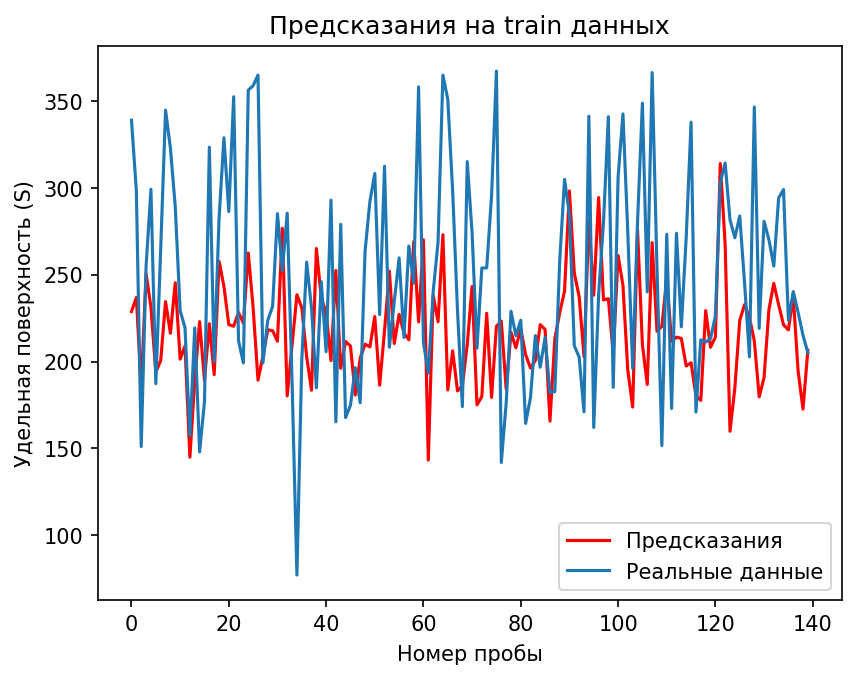

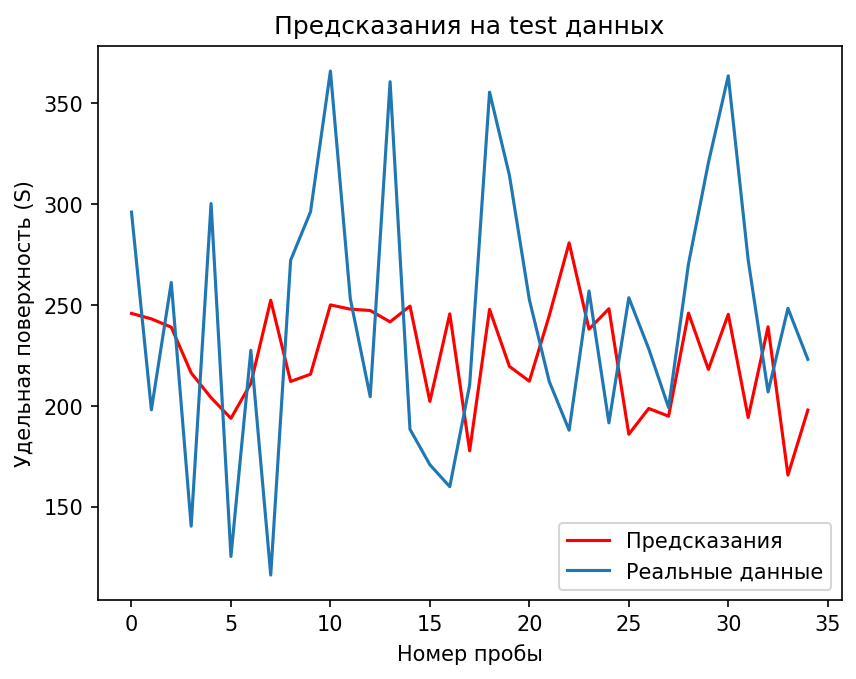

In [38]:
train_pred = pinn(
        torch.tensor(data['t_bc2_train'], dtype=torch.float32),
        torch.tensor(data['z_bc2_train'], dtype=torch.float32),
        torch.tensor(data['v_bc2_train'], dtype=torch.float32),
        )
train_pred = train_pred.detach()

test_pred = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        )
test_pred = test_pred.detach()

plt.figure(dpi=150)
plt.plot(train_pred.numpy()-50, c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.plot(test_pred.numpy()-50, c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

In [40]:
torch.save({
                'model_state_dict': pinn.state_dict(),
            }, "pinn_0306.pt")

/var/folders/pw/9v35zrks1gj89m9hgtttxv1c0000gn/T/ipykernel_66067/1838505031.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(torch.ones(len(df_periodic)), dtype=torch.float32),


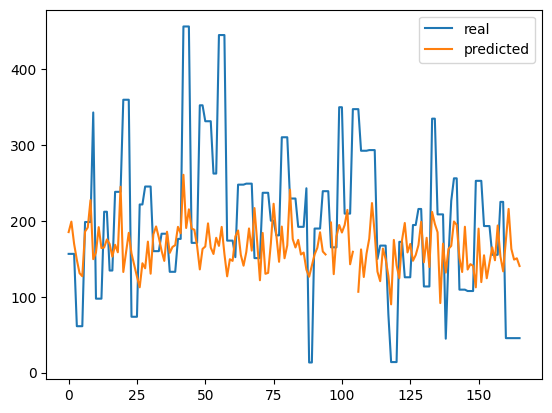

In [60]:
plt.plot(df_periodic['S_[m2/kg]'], label='real')
plt.plot(pinn(
        torch.tensor(df_periodic['residence_time_[s]'], dtype=torch.float32),
        torch.tensor(torch.ones(len(df_periodic)), dtype=torch.float32),
        torch.tensor(df_periodic['V_[m/s]'], dtype=torch.float32),
        ).detach().numpy()-100, label='predicted')
plt.legend()

# LALAL

In [1]:
from networks.PINN_S import PINN_S

In [14]:
pinn = PINN_S()

optimizer = optim.AdamW(pinn.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(100):
    pinn.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        pinn,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde=1.0, 
        lambda_bc1=0.0, 
        lambda_bc2=0.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {pinn.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        ).detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred))


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ


AttributeError: 'PINN_S' object has no attribute 'k'

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

t_pde = torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1,1).to(device)
z_pde = torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1,1).to(device)
v_pde = torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1,1).to(device)

t_bc1 = torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1,1).to(device)
z_bc1 = torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1,1).to(device)
v_bc1 = torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1,1).to(device)
S_bc1 = torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1,1).to(device)

t_bc2 = torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1,1).to(device)
z_bc2 = torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1,1).to(device)
v_bc2 = torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1,1).to(device)
S_bc2 = torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1,1).to(device)

t_ic = torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1,1).to(device)
z_ic = torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1,1).to(device)
v_ic = torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1,1).to(device)
S_ic = torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1,1).to(device)

optimizer = torch.optim.AdamW(
    pinn.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

In [20]:
epochs = 5000

history = []
test_history = []

for epoch in range(epochs):

    pinn.train()
    optimizer.zero_grad()

    loss, loss_pde, loss_bc1, loss_bc2 = pinn_loss_v2(
        pinn,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),

        lambda_pde = 1.0,
        lambda_bc1 = 10.0,
        lambda_bc2 = 10.0,
        lambda_ic  = 10.0
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        pinn.parameters(),
        max_norm=1.0
    )

    optimizer.step()

KeyboardInterrupt: 

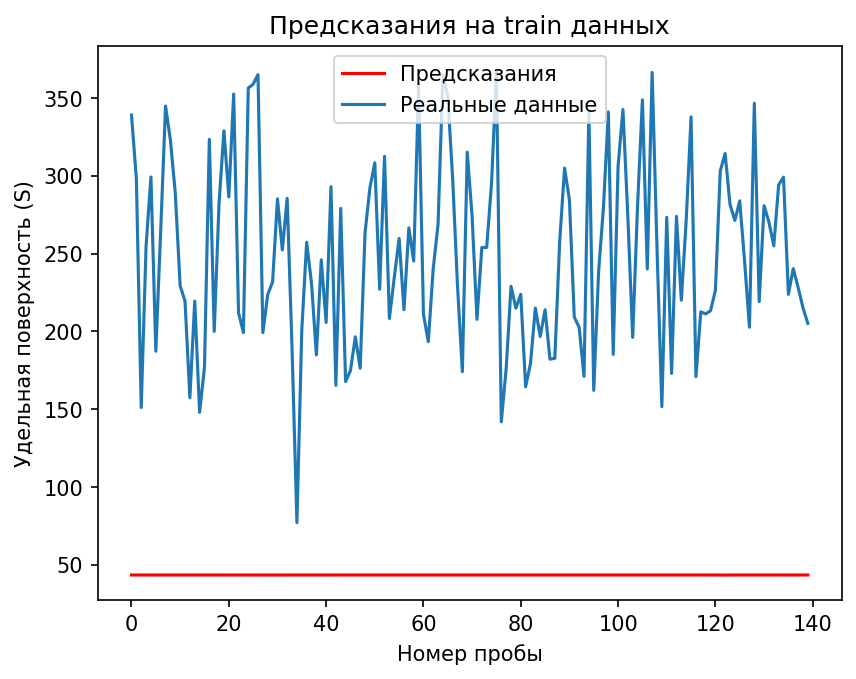

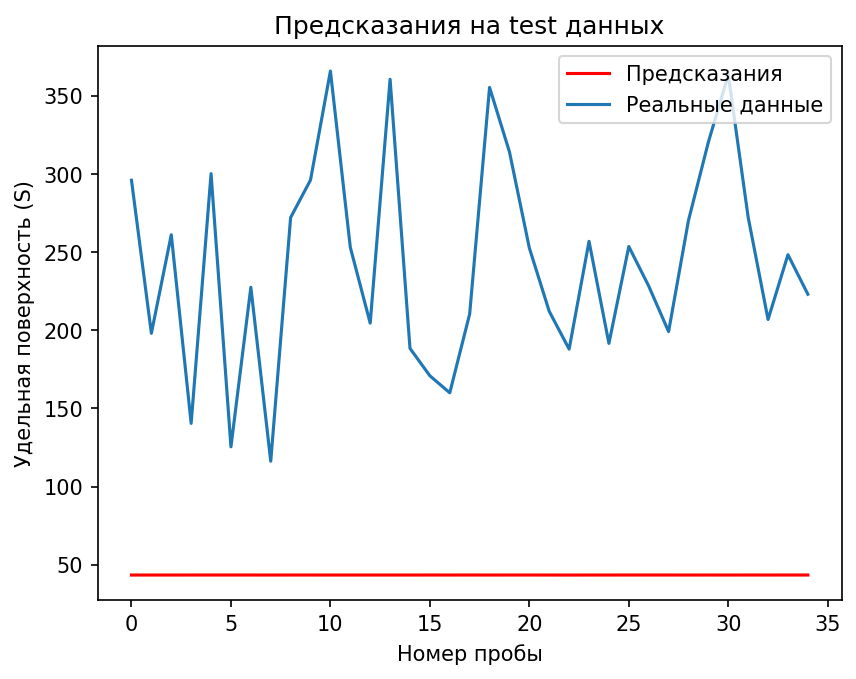

In [21]:
train_pred = pinn(
        torch.tensor(data['t_bc2_train'], dtype=torch.float32),
        torch.tensor(data['z_bc2_train'], dtype=torch.float32),
        torch.tensor(data['v_bc2_train'], dtype=torch.float32),
        )
train_pred = train_pred.detach()

test_pred = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        )
test_pred = test_pred.detach()

plt.figure(dpi=150)
plt.plot(train_pred.numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.plot(test_pred.numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()